In [20]:
import numpy as np
import phate, magic
import scprep
import matplotlib.pyplot as plt
import leidenalg
import seaborn as sns
import os
from sklearn import cluster

In [145]:
dataset = '3_branches'

In [22]:
names = ['GSPA_QR', 'DiffusionEMD', 'GAE_att_Gcell', 'GAE_noatt_Gcell', 'MAGIC',
       'Node2Vec_Gcell', 'Signals', 'GSPA', 'GAE_att_Ggene',
       'GAE_noatt_Ggene', 'Node2Vec_Ggene', 'Eigenscore', 'GFMMD']

clist = ['black', 'light yellow', 'purple', 'forest', 'mustard', 'teal',
         'berry', 'gray', 'light purple', 'light forest', 'light teal', 'white', 'sienna']

colors = {'mustard': '#E1AD01', 'berry': '#AC2F3D', 'teal': '#216E76', 'purple':'#502A4F', 'forest': '#065535', 'light forest': '#519167',
          'light yellow': '#E3BC81', 'light berry': '#c7505d', 'light teal': '#81ABA1', 'light purple': '#95636E', 'black': '#000000', 'gray':'#808080', 'white':'white', 'sienna':'sienna'}

cmap = {0: 'berry', 1:'light teal', 2:'mustard', 3:'forest', 4:'light purple'}

In [97]:
trajectory_data = np.load(f'../data/splatter_simulated_data_{dataset}.npz')
data = trajectory_data['data']
true_counts = trajectory_data['true_counts']
true_lib_size = true_counts.T.sum(axis=1)
time = trajectory_data['pseudotime'] / 10000

In [100]:
cell_phate_op = phate.PHATE(random_state=1234)
cell_data_phate = cell_phate_op.fit_transform(data)

cell_phate_op = phate.PHATE(random_state=1234)
true_cell_data_phate = cell_phate_op.fit_transform(true_counts)

Calculating PHATE...
  Running PHATE on 10000 observations and 8820 variables.
  Calculating graph and diffusion operator...
    Calculating PCA...
    Calculated PCA in 5.37 seconds.
    Calculating KNN search...
    Calculated KNN search in 9.23 seconds.
    Calculating affinities...
    Calculated affinities in 8.24 seconds.
  Calculated graph and diffusion operator in 22.87 seconds.
  Calculating landmark operator...
    Calculating SVD...
    Calculated SVD in 2.10 seconds.
    Calculating KMeans...
    Calculated KMeans in 3.15 seconds.
  Calculated landmark operator in 6.68 seconds.
  Calculating optimal t...
    Automatically selected t = 5
  Calculated optimal t in 1.86 seconds.
  Calculating diffusion potential...
  Calculated diffusion potential in 0.39 seconds.
  Calculating metric MDS...
  Calculated metric MDS in 4.15 seconds.
Calculated PHATE in 35.96 seconds.
Calculating PHATE...
  Running PHATE on 10000 observations and 8820 variables.
  Calculating graph and diffusion

<AxesSubplot:>

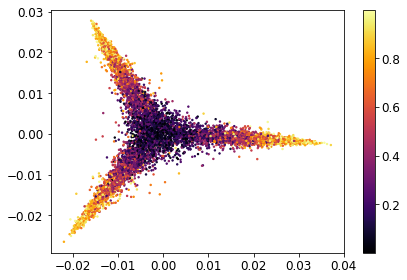

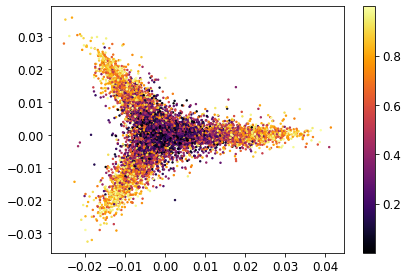

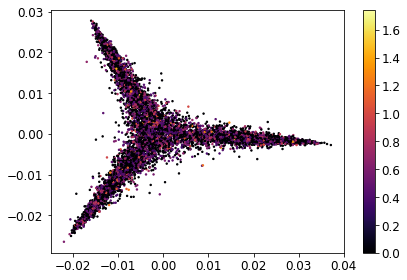

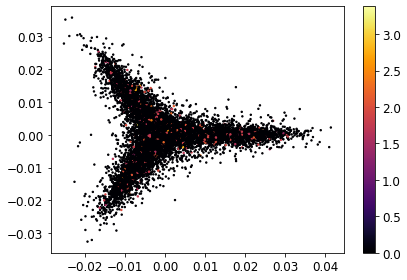

In [25]:
scprep.plot.scatter2d(true_cell_data_phate, time, filename=f'figures/noiseless_pseudotime_{dataset}.png', dpi=200)
scprep.plot.scatter2d(cell_data_phate, time, filename=f'figures/noisy_pseudotime_{dataset}.png', dpi=200)
scprep.plot.scatter2d(true_cell_data_phate, true_counts[:, 3422], filename=f'figures/noiseless_gene_{dataset}.png', dpi=200)
scprep.plot.scatter2d(cell_data_phate, data[:, 3422], filename=f'figures/noisy_gene_{dataset}.png', dpi=200)

In [146]:
embedding = np.load(f'../results/coexpression/GSPA_QR/0_results_{dataset}.npz')['signal_embedding']
localization_score = np.load(f'../results/coexpression/GSPA_QR/0_results_{dataset}.npz')['localization_score']

In [147]:
gene_phate_op = phate.PHATE(random_state=1234)
gene_data_phate = gene_phate_op.fit_transform(embedding)

Calculating PHATE...
  Running PHATE on 8823 observations and 128 variables.
  Calculating graph and diffusion operator...
    Calculating PCA...
    Calculated PCA in 0.18 seconds.
    Calculating KNN search...
    Calculated KNN search in 6.25 seconds.
    Calculating affinities...
    Calculated affinities in 4.40 seconds.
  Calculated graph and diffusion operator in 10.85 seconds.
  Calculating landmark operator...
    Calculating SVD...
    Calculated SVD in 1.41 seconds.
    Calculating KMeans...
    Calculated KMeans in 2.23 seconds.
  Calculated landmark operator in 4.66 seconds.
  Calculating optimal t...
    Automatically selected t = 11
  Calculated optimal t in 1.97 seconds.
  Calculating diffusion potential...
  Calculated diffusion potential in 0.36 seconds.
  Calculating metric MDS...
  Calculated metric MDS in 5.51 seconds.
Calculated PHATE in 23.35 seconds.


In [137]:
gene_clusters = cluster.KMeans(n_clusters=5).fit_predict(embedding)

In [139]:
conv ={0:0, 1:1, 2:2, 3:4, 4:3}
gene_clusters = [conv[x] for x in gene_clusters] # for visualization

In [98]:
magic_op = magic.MAGIC(random_state=1234)
data_magic = magic_op.fit_transform(true_counts)

Calculating MAGIC...
  Running MAGIC on 10000 cells and 8820 genes.
  Calculating graph and diffusion operator...
    Calculating PCA...
    Calculated PCA in 5.06 seconds.
    Calculating KNN search...
    Calculated KNN search in 8.95 seconds.
    Calculating affinities...
    Calculated affinities in 8.95 seconds.
  Calculated graph and diffusion operator in 22.97 seconds.
  Running MAGIC with `solver='exact'` on 8820-dimensional data may take a long time. Consider denoising specific genes with `genes=<list-like>` or using `solver='approximate'`.
  Calculating imputation...
  Calculated imputation in 4.53 seconds.
Calculated MAGIC in 27.55 seconds.


In [ ]:
scprep.plot.scatter2d(gene_data_phate, marker='^', c=gene_clusters, cmap='Spectral',
                      discrete=True, s=50, ticks=None, figsize=(5,5), filename=f'figures/GSPA_QR_gene_clusters_{dataset}.png', dpi=200)

<AxesSubplot:>

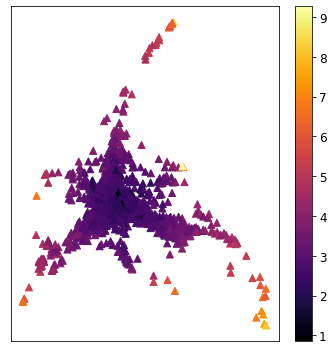

In [148]:
scprep.plot.scatter2d(gene_data_phate, marker='^', c=localization_score,s=50, ticks=None, figsize=(5,5), filename=f'figures/GSPA_QR_localization_score_{dataset}.png', dpi=200)

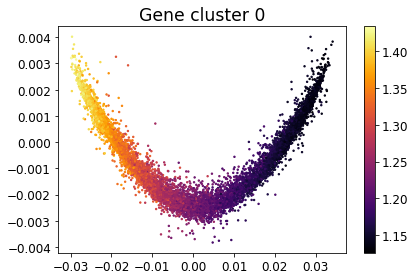

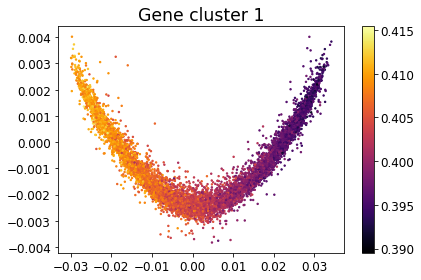

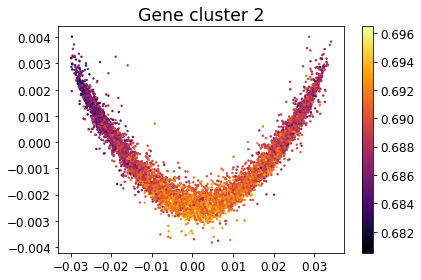

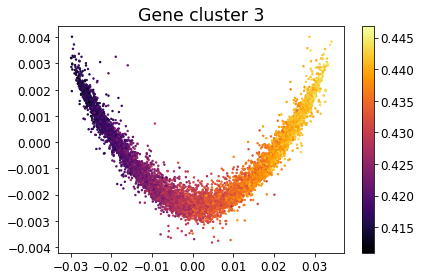

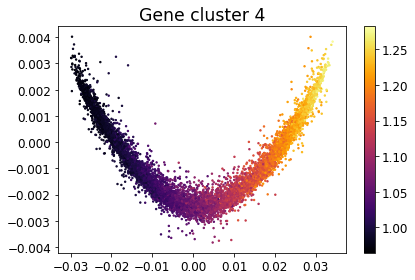

In [141]:
for c in np.unique(gene_clusters):
    scprep.plot.scatter2d(true_cell_data_phate,
                          c=data_magic[:, gene_clusters == c].mean(axis=1),
                          title=f'Gene cluster {c}', filename=f'figures/gene_cluster_{c}_{dataset}.png', dpi=200)